# Import

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import mlflow
import joblib
from mlflow.tracking import MlflowClient

# =========================================================
# 0) Connexion MLflow
# =========================================================
TRACKING_URI = "http://127.0.0.1:5000"
EXP_NAME = "Robustness_Test_Data_Simulation"
DL_DIR = "mlflow_import"

os.makedirs(DL_DIR, exist_ok=True)

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

exp = mlflow.get_experiment_by_name(EXP_NAME)
if exp is None:
    raise ValueError(f"Experiment introuvable: {EXP_NAME}")

runs = mlflow.search_runs([exp.experiment_id], output_format="pandas")
if runs.empty:
    raise ValueError("Aucun run trouvé.")

runs = runs.sort_values("start_time", ascending=False).reset_index(drop=True)
print("✅ runs:", len(runs))

# =========================================================
# Helpers
# =========================================================
def list_artifacts_recursive(run_id: str, path: str = ""):
    out = []
    stack = [path]
    while stack:
        p = stack.pop()
        try:
            items = client.list_artifacts(run_id, p)
        except Exception:
            continue
        for a in items:
            out.append(a)
            if a.is_dir:
                stack.append(a.path)
    return out

def download(run_id: str, artifact_path: str):
    return client.download_artifacts(run_id, artifact_path, dst_path=DL_DIR)

def find_first(run_id: str, pred):
    for a in list_artifacts_recursive(run_id):
        if a.is_dir:
            continue
        if pred(a):
            return a.path
    return None

def find_all(run_id: str, pred):
    paths = []
    for a in list_artifacts_recursive(run_id):
        if a.is_dir:
            continue
        if pred(a):
            paths.append(a.path)
    return paths

def _load_json(local_path: str):
    with open(local_path, "r", encoding="utf-8") as f:
        return json.load(f)

# =========================================================
# 1) Dernier run par (model_label, partition)
# =========================================================
runs["model_label"] = runs["tags.model_label"] if "tags.model_label" in runs.columns else None
runs["partition"]   = runs["tags.partition"] if "tags.partition" in runs.columns else None

runs_ok = runs.dropna(subset=["model_label", "partition"]).copy()
runs_ok["model_label"] = runs_ok["model_label"].astype(str)
runs_ok["partition"]   = runs_ok["partition"].astype(str)

runs_latest = (
    runs_ok.sort_values("start_time", ascending=False)
           .drop_duplicates(subset=["model_label", "partition"], keep="first")
           .reset_index(drop=True)
)

print("✅ unique (model,partition) runs:", len(runs_latest))

# =========================================================
# 2) Recharger l'état complet : meta_models + ts_lr
# =========================================================
meta_models = None
ts_lr = None

for _, r in runs_latest.iterrows():
    rid = r["run_id"]

    if meta_models is None:
        p = find_first(rid, lambda a: a.path.endswith("full_state/meta_models.pkl"))
        if p:
            local = download(rid, p)
            with open(local, "rb") as f:
                meta_models = pickle.load(f)
            print("✅ meta_models loaded")

    if ts_lr is None:
        p = find_first(rid, lambda a: a.path.endswith("full_state/ts_lr.parquet"))
        if p:
            local = download(rid, p)
            ts_lr = pd.read_parquet(local)
            print("✅ ts_lr loaded:", ts_lr.shape)

    if meta_models is not None and ts_lr is not None:
        break

# =========================================================
# 3) Tables globales
# =========================================================
score_df_exp = None
leaderboard_exp = None

for _, r in runs_latest.iterrows():
    rid = r["run_id"]

    if score_df_exp is None:
        p = find_first(rid, lambda a: os.path.basename(a.path) == "score_df_exp.csv")
        if p:
            score_df_exp = pd.read_csv(download(rid, p))
            print("✅ score_df_exp loaded:", score_df_exp.shape, "|", p)

    if leaderboard_exp is None:
        p = find_first(rid, lambda a: os.path.basename(a.path) == "leaderboard_exp.csv")
        if p:
            leaderboard_exp = pd.read_csv(download(rid, p))
            print("✅ leaderboard_exp loaded:", leaderboard_exp.shape, "|", p)

    if score_df_exp is not None and leaderboard_exp is not None:
        break

# =========================================================
# 4) Explainability PAR PARTITION
# =========================================================
results_perm_mae_by_part = {}
results_perm_dev_by_part = {}
results_shap_share_by_part = {}

def collect_explainability(run_id: str):
    for a in list_artifacts_recursive(run_id):
        if a.is_dir or not a.path.endswith(".csv"):
            continue

        base = os.path.basename(a.path)

        if base.startswith("perm_mae_"):
            name = base.replace("perm_mae_", "").replace(".csv", "")
            if "_" in name:
                model_label, partition = name.split("_", 1)
                df = pd.read_csv(download(run_id, a.path))
                results_perm_mae_by_part.setdefault(partition, {})[model_label] = df

        elif base.startswith("perm_dev_"):
            name = base.replace("perm_dev_", "").replace(".csv", "")
            if "_" in name:
                model_label, partition = name.split("_", 1)
                df = pd.read_csv(download(run_id, a.path))
                results_perm_dev_by_part.setdefault(partition, {})[model_label] = df

        elif base.startswith("shap_"):
            name = base.replace("shap_", "").replace(".csv", "")
            if "_" in name:
                model_label, partition = name.split("_", 1)
                df = pd.read_csv(download(run_id, a.path))
                results_shap_share_by_part.setdefault(partition, {})[model_label] = df

for _, r in runs_latest.iterrows():
    collect_explainability(r["run_id"])

print("✅ partitions perm_mae:", sorted(results_perm_mae_by_part.keys()))
print("✅ partitions perm_dev:", sorted(results_perm_dev_by_part.keys()))
print("✅ partitions shap:", sorted(results_shap_share_by_part.keys()))

# =========================================================
# 5) bkt parquet par (model, partition)
# =========================================================
bkt_by_run = {}

for _, r in runs_latest.iterrows():
    model_label = str(r["model_label"])
    partition   = str(r["partition"])
    run_id      = r["run_id"]

    fname = f"bkt_{model_label}_{partition}.parquet"
    p = find_first(run_id, lambda a: os.path.basename(a.path) == fname)
    if p:
        local = download(run_id, p)
        bkt_by_run[(model_label, partition)] = pd.read_parquet(local)

print("✅ bkt parquet loaded:", len(bkt_by_run))

# =========================================================
# 6) X parquet + features json
# =========================================================
X_by_run = {}
features_by_run = {}

def _parse_model_partition_from_filename(base: str):
    if base.startswith("X_") and base.endswith(".parquet"):
        name = base.replace("X_", "").replace(".parquet", "")
    elif base.startswith("features_") and base.endswith(".json"):
        name = base.replace("features_", "").replace(".json", "")
    else:
        return None

    if "_" not in name:
        return None

    model_label, partition = name.split("_", 1)
    return model_label, partition

def collect_functional_data(run_id: str):
    x_paths = find_all(
        run_id,
        lambda a: (
            (a.path.startswith("functional/") or a.path.startswith("X/") or "/X_" in a.path)
            and os.path.basename(a.path).startswith("X_")
            and a.path.endswith(".parquet")
        )
    )

    for p in x_paths:
        base = os.path.basename(p)
        mp = _parse_model_partition_from_filename(base)
        if mp is None:
            continue
        model_label, partition = mp
        local = download(run_id, p)
        X_by_run[(model_label, partition)] = pd.read_parquet(local)

    f_paths = find_all(
        run_id,
        lambda a: (
            (a.path.startswith("functional/") or a.path.startswith("X/") or "/features_" in a.path)
            and os.path.basename(a.path).startswith("features_")
            and a.path.endswith(".json")
        )
    )

    for p in f_paths:
        base = os.path.basename(p)
        mp = _parse_model_partition_from_filename(base)
        if mp is None:
            continue
        model_label, partition = mp
        local = download(run_id, p)
        j = _load_json(local)

        if isinstance(j, list):
            feats = j
        elif isinstance(j, dict):
            feats = j.get("features", [])
        else:
            feats = []

        if isinstance(feats, list):
            features_by_run[(model_label, partition)] = feats

for _, r in runs_latest.iterrows():
    collect_functional_data(r["run_id"])

print("✅ X parquet loaded:", len(X_by_run))
print("✅ features json loaded:", len(features_by_run))
if X_by_run:
    k0 = list(X_by_run.keys())[0]
    print("Example X:", k0, X_by_run[k0].shape)

# =========================================================
# 7) preproc pickle
# =========================================================
preprocs_by_run = {}

def collect_preproc_data(run_id: str):
    p_paths = find_all(
        run_id,
        lambda a: (
            os.path.basename(a.path).startswith("preproc_")
            and a.path.endswith(".pkl")
        )
    )

    for p in p_paths:
        base = os.path.basename(p)
        name = base.replace("preproc_", "").replace(".pkl", "")
        if "_" not in name:
            continue

        model_label, partition = name.split("_", 1)

        try:
            local = download(run_id, p)
            with open(local, "rb") as f:
                preprocs_by_run[(model_label, partition)] = pickle.load(f)
        except Exception:
            pass

for _, r in runs_latest.iterrows():
    collect_preproc_data(r["run_id"])

print("✅ preproc loaded:", len(preprocs_by_run))

# =========================================================
# 8) Chargement des modèles
# =========================================================
models_mlflow = {}

def has_model_dir(run_id):
    try:
        return any(a.is_dir and a.path == "model" for a in client.list_artifacts(run_id, ""))
    except Exception:
        return False

def find_preferred_model_file(run_id, model_label, partition):
    p = find_first(run_id, lambda a: os.path.basename(a.path) == f"estimator_{model_label}_{partition}.joblib")
    if p:
        return p

    p = find_first(run_id, lambda a: os.path.basename(a.path) == f"model_{model_label}_{partition}.joblib")
    if p:
        return p

    p = find_first(run_id, lambda a: a.path.startswith("model/") and a.path.lower().endswith((".joblib", ".pkl")))
    if p:
        return p

    p = find_first(run_id, lambda a: a.path.lower().endswith((".joblib", ".pkl")))
    return p

for _, r in runs_latest.iterrows():
    model_label = str(r["model_label"])
    partition   = str(r["partition"])
    run_id      = r["run_id"]
    key = (model_label, partition)

    p = find_preferred_model_file(run_id, model_label, partition)
    if p:
        try:
            local = download(run_id, p)
            models_mlflow[key] = joblib.load(local)
            continue
        except Exception:
            pass

    if has_model_dir(run_id):
        try:
            models_mlflow[key] = mlflow.pyfunc.load_model(f"runs:/{run_id}/model")
            continue
        except Exception:
            pass

print("✅ loaded models:", len(models_mlflow))
print("Example keys:", list(models_mlflow.keys())[:5])

# =========================================================
# 9) Construire directement les objets functional-grid
#    à partir de meta_models["metas"]
# =========================================================
def build_functional_inputs_from_meta(
    *,
    meta_models: dict,
    ts_data: pd.DataFrame,
    end_date=None,
    date_col: str = "ds",
    model_order=("LR", "RIDGE", "LGBM"),
):
    if not isinstance(meta_models, dict):
        raise ValueError("meta_models doit être un dict.")

    if "metas" not in meta_models or not isinstance(meta_models["metas"], dict) or len(meta_models["metas"]) == 0:
        raise ValueError("meta_models['metas'] est vide ou absent.")

    metas = meta_models["metas"]

    ts_base = ts_data.copy()
    ts_base[date_col] = (
        pd.to_datetime(ts_base[date_col], errors="coerce")
          .dt.to_period("M")
          .dt.to_timestamp(how="start")
          .dt.normalize()
    )
    ts_base = ts_base.dropna(subset=[date_col]).reset_index(drop=True)

    if end_date is not None:
        end_date = pd.Timestamp(end_date).to_period("M").to_timestamp(how="start").normalize()

    models_dict = {}
    X_dict = {}
    features_dict = {}

    for model_name in model_order:
        meta = metas.get(model_name, None)
        if meta is None:
            print(f"⚠️ Meta absente pour {model_name}")
            continue

        models_all = list(meta.get("fitted_models", []))
        dates_all = pd.to_datetime(meta.get("train_fit_dates", []), errors="coerce")
        feats_all = list(meta.get("features", [])) if meta.get("features", None) is not None else []
        prep_all = meta.get("preprocs", None)

        if len(models_all) == 0:
            print(f"⚠️ Aucun modèle fitted pour {model_name}")
            continue

        if len(feats_all) == 0:
            print(f"⚠️ Aucune feature trouvée pour {model_name}")
            continue

        if end_date is not None and len(dates_all) > 0:
            keep_idx = [i for i, d in enumerate(dates_all) if pd.notna(d) and d <= end_date]
            if len(keep_idx) == 0:
                print(f"⚠️ Aucun modèle {model_name} <= {end_date.date()}")
                continue
            last_i = keep_idx[-1]
        else:
            last_i = len(models_all) - 1

        model_selected = models_all[last_i]

        prep_selected = None
        if isinstance(prep_all, list) and len(prep_all) > last_i:
            prep_selected = prep_all[last_i]
        elif not isinstance(prep_all, list):
            prep_selected = prep_all

        needed_cols = [date_col] + [c for c in feats_all if c in ts_base.columns]
        if len(needed_cols) <= 1:
            print(f"⚠️ Aucune colonne feature disponible dans ts_data pour {model_name}")
            continue

        X_model = ts_base[needed_cols].copy()

        models_dict[model_name] = (model_selected, prep_selected)
        X_dict[model_name] = X_model
        features_dict[model_name] = feats_all

        print(f"✅ {model_name}: model ok | X shape={X_model.shape} | n_features={len(feats_all)}")

    return models_dict, X_dict, features_dict

models_dict, X_dict, features_dict = build_functional_inputs_from_meta(
    meta_models=meta_models,
    ts_data=ts_lr,
    end_date="2019-08-01",
    date_col="ds",
    model_order=("LR", "RIDGE", "LGBM"),
)

# =========================================================
# IMPORT SUMMARY
# =========================================================
print("\n================= IMPORT SUMMARY =================")
print("meta_models loaded:", meta_models is not None)
print("ts_lr:", None if ts_lr is None else ts_lr.shape)
print("score_df_exp:", None if score_df_exp is None else score_df_exp.shape)
print("leaderboard_exp:", None if leaderboard_exp is None else leaderboard_exp.shape)
print("perm_mae partitions:", len(results_perm_mae_by_part))
print("perm_dev partitions:", len(results_perm_dev_by_part))
print("shap partitions:", len(results_shap_share_by_part))
print("bkt_by_run:", len(bkt_by_run))
print("X_by_run:", len(X_by_run))
print("features_by_run:", len(features_by_run))
print("preprocs_by_run:", len(preprocs_by_run))
print("models_mlflow:", len(models_mlflow))
print("models_dict keys:", list(models_dict.keys()))
print("X_dict keys:", list(X_dict.keys()))
print("features_dict keys:", list(features_dict.keys()))
print("==================================================")

✅ runs: 15
✅ unique (model,partition) runs: 15


✅ meta_models loaded


✅ ts_lr loaded: (764, 13)


✅ score_df_exp loaded: (15, 14) | tables/score_df_exp.csv


✅ leaderboard_exp loaded: (10, 14) | tables/leaderboard_exp.csv


✅ partitions perm_mae: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']
✅ partitions perm_dev: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']
✅ partitions shap: ['1990-1999', '2000-2008', '2009-2019', '2020-end', 'ALL']


✅ bkt parquet loaded: 15
✅ X parquet loaded: 0
✅ features json loaded: 0
✅ preproc loaded: 0


✅ loaded models: 15
Example keys: [('RIDGE', 'ALL'), ('LR', 'ALL'), ('LGBM', 'ALL'), ('RIDGE', '2020-end'), ('RIDGE', '2009-2019')]
⚠️ Aucune feature trouvée pour LR
⚠️ Aucune feature trouvée pour RIDGE
⚠️ Aucune feature trouvée pour LGBM

================= IMPORT SUMMARY =================
meta_models loaded: True
ts_lr: (764, 13)
score_df_exp: (15, 14)
leaderboard_exp: (10, 14)
perm_mae partitions: 5
perm_dev partitions: 5
shap partitions: 5
bkt_by_run: 15
X_by_run: 0
features_by_run: 0
preprocs_by_run: 0
models_mlflow: 15
models_dict keys: []
X_dict keys: []
features_dict keys: []


# Vérification

In [2]:
# =========================================================
# Diagnostic de toutes les tables bkt_by_run
# =========================================================
summary_rows = []

for (model_label, partition), df in bkt_by_run.items():
    cols = list(df.columns)
    summary_rows.append({
        "model_label": model_label,
        "partition": partition,
        "n_rows": len(df),
        "n_cols": len(cols),
        "columns": cols,
        "has_ds": "ds" in cols,
        "has_y_true": "y_true" in cols,
        "has_y": "y" in cols,
        "has_y_hat": "y_hat" in cols,
        "has_model_named_col": model_label in cols,
    })

diag_bkt = pd.DataFrame(summary_rows).sort_values(["model_label", "partition"]).reset_index(drop=True)

pd.set_option("display.max_colwidth", None)
display(diag_bkt)

,model_label,partition,n_rows,n_cols,columns,has_ds,has_y_true,has_y,has_y_hat,has_model_named_col
0,LGBM,1990-1999,120,8,"[unique_id, ds, cutoff, y, LGBM, LGBM-lo-95, LGBM-hi-95, partition]",True,False,True,False,True
1,LGBM,2000-2008,108,8,"[unique_id, ds, cutoff, y, LGBM, LGBM-lo-95, LGBM-hi-95, partition]",True,False,True,False,True
2,LGBM,2009-2019,132,8,"[unique_id, ds, cutoff, y, LGBM, LGBM-lo-95, LGBM-hi-95, partition]",True,False,True,False,True
3,LGBM,2020-end,68,8,"[unique_id, ds, cutoff, y, LGBM, LGBM-lo-95, LGBM-hi-95, partition]",True,False,True,False,True
4,LGBM,ALL,428,8,"[unique_id, ds, cutoff, y, LGBM, LGBM-lo-95, LGBM-hi-95, partition]",True,False,True,False,True
5,LR,1990-1999,120,8,"[unique_id, ds, cutoff, y, LR, LR-lo-95, LR-hi-95, partition]",True,False,True,False,True
6,LR,2000-2008,108,8,"[unique_id, ds, cutoff, y, LR, LR-lo-95, LR-hi-95, partition]",True,False,True,False,True
7,LR,2009-2019,132,8,"[unique_id, ds, cutoff, y, LR, LR-lo-95, LR-hi-95, partition]",True,False,True,False,True
8,LR,2020-end,68,8,"[unique_id, ds, cutoff, y, LR, LR-lo-95, LR-hi-95, partition]",True,False,True,False,True
9,LR,ALL,428,8,"[unique_id, ds, cutoff, y, LR, LR-lo-95, LR-hi-95, partition]",True,False,True,False,True


In [3]:
print("X_by_run:", len(X_by_run))
print("features_by_run:", len(features_by_run))
print("X_by_run keys:", list(X_by_run.keys())[:10])
print("X_dict keys:", list(X_dict.keys()))

X_by_run: 0
features_by_run: 0
X_by_run keys: []
X_dict keys: []


# Contruire combined_bkt

In [4]:
# =========================================================
# Reconstruction combined_bkt (adapté à ta structure)
# =========================================================
frames = []

for (model_label, partition), df in bkt_by_run.items():

    # ignorer les partitions vides
    if len(df) == 0:
        continue

    tmp = df.copy()

    # mapping colonnes
    tmp = tmp.rename(columns={
        "ds": "ds",
        "y": "y_true",
        model_label: "y_hat"
    })

    tmp["model_label"] = model_label
    tmp["partition"] = partition

    frames.append(
        tmp[["ds", "y_true", "y_hat", "model_label", "partition"]]
    )

combined_bkt = pd.concat(frames, ignore_index=True)

combined_bkt["ds"] = pd.to_datetime(combined_bkt["ds"], utc=True)

combined_bkt = combined_bkt.sort_values(["ds", "model_label"]).reset_index(drop=True)

print("combined_bkt shape:", combined_bkt.shape)
display(combined_bkt.head())

combined_bkt shape: (2568, 5)


,ds,y_true,y_hat,model_label,partition
0,1990-01-01 00:00:00+00:00,0.0,-0.135347,LGBM,ALL
1,1990-01-01 00:00:00+00:00,0.0,-0.135347,LGBM,1990-1999
2,1990-01-01 00:00:00+00:00,0.0,-0.143011,LR,ALL
3,1990-01-01 00:00:00+00:00,0.0,-0.143011,LR,1990-1999
4,1990-01-01 00:00:00+00:00,0.0,-0.100528,RIDGE,ALL


# MAE

In [5]:
import numpy as np
import pandas as pd
from math import sqrt, erf, isfinite
from typing import Iterable, Optional, Dict, List, Tuple

# ============================================================
# 1) DM test helpers
# ============================================================
def _phi(z: float) -> float:
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def dm_pvalue(loss_diff: np.ndarray, lags: int = 0) -> float:
    x = np.asarray(loss_diff, dtype=float)
    x = x[np.isfinite(x)]
    T = x.size
    if T < 3:
        return np.nan

    dbar = x.mean()
    gamma0 = np.dot(x - dbar, x - dbar) / T
    var = gamma0

    if lags > 0:
        for k in range(1, min(lags, T - 1) + 1):
            w = 1.0 - k / (lags + 1.0)
            cov = np.dot(x[k:] - dbar, x[:-k] - dbar) / T
            var += 2.0 * w * cov

    if var <= 0:
        return np.nan

    stat = dbar / sqrt(var / T)
    p = 2.0 * (1.0 - _phi(abs(stat)))
    return max(0.0, min(1.0, p))


# ============================================================
# 2) combined_bkt -> wide
# ============================================================
def combined_bkt_to_wide_true_pred(
    combined_bkt: pd.DataFrame,
    *,
    date_col: str = "ds",
    true_col: str = "y_true",
    pred_col: str = "y_hat",
    model_col: str = "model_label",
    methods: Optional[Iterable[str]] = None,
) -> pd.DataFrame:
    df = combined_bkt.copy()
    df[date_col] = pd.to_datetime(df[date_col], utc=True, errors="coerce")
    df = df.dropna(subset=[date_col])

    if methods is None:
        methods = sorted(df[model_col].dropna().astype(str).unique().tolist())
    else:
        methods = [m for m in methods if m in set(df[model_col].dropna().astype(str))]

    pred_wide = (
        df[df[model_col].astype(str).isin(list(methods))]
        .pivot_table(index=date_col, columns=model_col, values=pred_col, aggfunc="last")
        .sort_index()
    )

    true_ser = (
        df.groupby(date_col)[true_col]
          .apply(lambda s: s.dropna().iloc[0] if s.dropna().shape[0] else np.nan)
          .sort_index()
    )

    wide = pred_wide.copy()
    wide.insert(0, "true", true_ser)
    wide = wide[["true"] + [c for c in methods if c in wide.columns]]
    return wide


# ============================================================
# 3) MAE pivot + DM p-values
# ============================================================
def make_mae_dm_pivot_same_dates(
    wide: pd.DataFrame,
    segments: List[Tuple[str, Optional[str], str]],
    *,
    methods: Optional[Iterable[str]] = None,
    include_overall: bool = True,
    overall_label: str = "Ensemble",
    min_obs: int = 20,
    round_digits: int = 4,
    add_dm: bool = True,
    dm_lags: int = 11,
) -> pd.DataFrame:

    df = wide.copy()

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
        df = df.set_index("date")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("wide doit avoir un DatetimeIndex ou une colonne 'date'.")

    df = df.sort_index()

    if "true" not in df.columns:
        raise ValueError("wide doit contenir la colonne 'true'.")

    if methods is None:
        meths = [c for c in df.columns if c != "true"]
    else:
        meths = [m for m in methods if m in df.columns and m != "true"]

    if len(meths) == 0:
        return pd.DataFrame()

    full_start, full_end = df.index.min(), df.index.max()

    windows = []
    if include_overall:
        windows.append((full_start, full_end, overall_label))

    for start, end, label in segments:
        s = pd.to_datetime(start, utc=True)
        e = pd.to_datetime(end, utc=True) if end is not None else full_end
        windows.append((s, e, label))

    rows = []

    for start, end, label in windows:
        sub = df.loc[start:end, ["true"] + meths].copy().dropna(subset=["true"])

        err_abs = {}
        for m in meths:
            err_abs[m] = (sub["true"] - sub[m]).abs()

        maes_raw = {
            m: float(err_abs[m].dropna().mean()) if err_abs[m].dropna().shape[0] >= min_obs else np.nan
            for m in meths
        }
        finite = [m for m in meths if isfinite(maes_raw.get(m, np.nan))]
        best_m = min(finite, key=lambda k: maes_raw[k]) if finite else None

        for m in meths:
            if best_m is None:
                rows.append((m, label, np.nan))
                continue

            common = err_abs[m].dropna().index.intersection(err_abs[best_m].dropna().index)
            if common.size < min_obs:
                rows.append((m, label, np.nan))
                continue

            mae_val = float(err_abs[m].loc[common].mean())
            cell = f"{mae_val:.{round_digits}f}"

            if add_dm and m != best_m:
                diff = (err_abs[m].loc[common] - err_abs[best_m].loc[common]).to_numpy()
                pval = dm_pvalue(diff, lags=dm_lags)
                cell = f"{cell} ({pval:.3f})" if isfinite(pval) else f"{cell} (NaN)"

            rows.append((m, label, cell))

    out = pd.DataFrame(rows, columns=["model", "period", "value"])
    pivot = out.pivot(index="model", columns="period", values="value")

    desired_cols = ([overall_label] if include_overall else []) + [lbl for _, _, lbl in segments]
    pivot = pivot.reindex(columns=desired_cols)
    pivot = pivot.reindex(index=meths)

    pivot.columns.name = "period"
    pivot.index.name = "model"
    return pivot

In [6]:
# ============================================================
# 4) CALL
# ============================================================
segments = [
    ("1990-01-01", "1999-12-01", "1990-1999"),
    ("2000-01-01", "2008-12-01", "2000-2008"),
    ("2009-01-01", "2019-12-01", "2009-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

wide = combined_bkt_to_wide_true_pred(combined_bkt, methods=None)

table_mae_dm = make_mae_dm_pivot_same_dates(
    wide=wide,
    segments=segments,
    methods=None,
    include_overall=True,
    overall_label="Ensemble",
    min_obs=20,
    round_digits=4,
    add_dm=True,
    dm_lags=11,
)

display(table_mae_dm)

period,Ensemble,1990-1999,2000-2008,2009-2019,2020-fin
model,,,,,
LGBM,0.8608,0.5401,0.5984 (0.159),0.8702,1.8250
LR,0.9280 (0.032),0.5830 (0.476),0.5962 (0.597),0.9975 (0.000),1.9289 (0.443)
RIDGE,0.8997 (0.175),0.5704 (0.548),0.5750,0.9105 (0.032),1.9758 (0.271)


# Width

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from typing import List, Tuple, Optional, Iterable

# =========================================================
# 1) Wide width depuis combined_bkt
# =========================================================
def combined_bkt_to_wide_width(
    combined_bkt: pd.DataFrame,
    methods: Optional[Iterable[str]] = None,
    date_col: str = "ds",
    model_col: str = "model_label",
    width_col: str = "width",
) -> pd.DataFrame:
    df = combined_bkt.copy()
    df[date_col] = pd.to_datetime(df[date_col], utc=True, errors="coerce")
    df = df.dropna(subset=[date_col])

    if methods is None:
        methods = sorted(df[model_col].dropna().astype(str).unique().tolist())
    else:
        methods = [m for m in methods if m in set(df[model_col].dropna().astype(str))]

    df = df[df[model_col].astype(str).isin(list(methods))].copy()

    wide = (
        df.pivot_table(index=date_col, columns=model_col, values=width_col, aggfunc="last")
          .sort_index()
    )

    wide = wide[[m for m in methods if m in wide.columns]]
    return wide


# =========================================================
# 2) Paired t-test p-value entre deux modèles
# =========================================================
def paired_t_pvalue(w1: pd.Series, w2: pd.Series, min_obs: int = 30) -> float:
    common = w1.index.intersection(w2.index)
    a = w1.loc[common].dropna()
    b = w2.loc[common].dropna()

    common2 = a.index.intersection(b.index)
    a = a.loc[common2].astype(float)
    b = b.loc[common2].astype(float)

    if len(a) < min_obs:
        return np.nan

    return float(ttest_rel(a, b).pvalue)


# =========================================================
# 3) Table width + p-value vs meilleur
# =========================================================
def make_width_ttest_pivot(
    combined_bkt: pd.DataFrame,
    segments: List[Tuple[str, Optional[str], str]],
    *,
    methods: Optional[Iterable[str]] = None,
    include_overall: bool = True,
    overall_label: str = "Ensemble",
    min_obs: int = 30,
    round_digits: int = 4,
    add_test: bool = True,
) -> pd.DataFrame:

    wide = combined_bkt_to_wide_width(combined_bkt, methods=methods)
    meths = list(wide.columns)

    full_start, full_end = wide.index.min(), wide.index.max()

    windows = []
    if include_overall:
        windows.append((full_start, full_end, overall_label))

    for start, end, label in segments:
        s = pd.to_datetime(start, utc=True)
        e = pd.to_datetime(end, utc=True) if end is not None else full_end
        windows.append((s, e, label))

    rows = []

    for start, end, label in windows:
        sub = wide.loc[start:end, meths].copy()

        means = {
            m: float(sub[m].dropna().mean()) if sub[m].dropna().shape[0] >= min_obs else np.nan
            for m in meths
        }

        finite = [m for m in meths if np.isfinite(means.get(m, np.nan))]
        best = min(finite, key=lambda k: means[k]) if finite else None

        for m in meths:
            mean_val = means.get(m, np.nan)

            if not np.isfinite(mean_val) or best is None:
                rows.append((m, label, np.nan))
                continue

            cell = f"{mean_val:.{round_digits}f}"

            if add_test and m != best:
                p = paired_t_pvalue(sub[m], sub[best], min_obs=min_obs)
                cell = f"{cell} ({p:.3f})" if np.isfinite(p) else f"{cell} (NaN)"

            rows.append((m, label, cell))

    out = pd.DataFrame(rows, columns=["model", "period", "value"])
    pivot = out.pivot(index="model", columns="period", values="value")

    desired_cols = ([overall_label] if include_overall else []) + [lbl for _, _, lbl in segments]
    pivot = pivot.reindex(columns=desired_cols)
    pivot = pivot.reindex(index=meths)

    pivot.columns.name = "period"
    pivot.index.name = "model"
    return pivot


# =========================================================
# 4) Construire combined_bkt_width à partir de bkt_by_run
# =========================================================
frames = []

for (model_label, partition), df in bkt_by_run.items():
    if len(df) == 0:
        continue

    lo_col = f"{model_label}-lo-95"
    hi_col = f"{model_label}-hi-95"

    if lo_col not in df.columns or hi_col not in df.columns:
        continue

    tmp = df.copy().rename(columns={
        "ds": "ds",
        "y": "y_true",
        model_label: "y_hat",
        lo_col: "lo_95",
        hi_col: "hi_95",
    })

    tmp["width"] = tmp["hi_95"] - tmp["lo_95"]
    tmp["model_label"] = model_label
    tmp["partition"] = partition

    frames.append(
        tmp[["ds", "y_true", "y_hat", "lo_95", "hi_95", "width", "model_label", "partition"]]
    )

combined_bkt_width = pd.concat(frames, ignore_index=True)
combined_bkt_width["ds"] = pd.to_datetime(combined_bkt_width["ds"], utc=True, errors="coerce")
combined_bkt_width = (
    combined_bkt_width
    .dropna(subset=["ds"])
    .sort_values(["ds", "model_label"])
    .reset_index(drop=True)
)

# =========================================================
# 5) Appel
# =========================================================
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2009-01-01", "2019-12-31", "2009-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

width_table = make_width_ttest_pivot(
    combined_bkt=combined_bkt_width,
    segments=segments,
    methods=["LGBM", "LR", "RIDGE"],   # ordre souhaité
    include_overall=True,
    overall_label="Ensemble",
    min_obs=30,
    round_digits=4,
    add_test=True,
)

print(width_table.to_string())

period        Ensemble       1990-1999       2000-2008       2009-2019        2020-fin
model                                                                                 
LGBM            2.8940  1.7456 (0.765)          1.4861          3.1672          6.6263
LR      3.1775 (0.000)  1.9207 (0.000)  1.6643 (0.000)  3.4751 (0.000)  7.2212 (0.007)
RIDGE   3.0228 (0.001)          1.7309  1.5242 (0.018)  3.2695 (0.000)  7.2036 (0.008)


# Coverage

In [8]:
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
from typing import List, Tuple, Optional, Iterable

# =========================================================
# 1) Helper: pivot covered (0/1)
# =========================================================
def combined_bkt_to_wide_covered(
    combined_bkt: pd.DataFrame,
    methods: Optional[Iterable[str]] = None,
    date_col: str = "ds",
    model_col: str = "model_label",
    covered_col: str = "covered",
) -> pd.DataFrame:
    df = combined_bkt.copy()
    df[date_col] = pd.to_datetime(df[date_col], utc=True, errors="coerce")
    df = df.dropna(subset=[date_col])

    if methods is None:
        methods = sorted(df[model_col].dropna().astype(str).unique().tolist())
    else:
        methods = [m for m in methods if m in set(df[model_col].dropna().astype(str))]

    df = df[df[model_col].astype(str).isin(list(methods))].copy()

    wide = (
        df.pivot_table(index=date_col, columns=model_col, values=covered_col, aggfunc="last")
          .sort_index()
    )

    wide = wide[[m for m in methods if m in wide.columns]]
    return wide


# =========================================================
# 2) McNemar p-value entre 2 modèles
# =========================================================
def mcnemar_pvalue_from_pairs(
    c1: pd.Series,
    c2: pd.Series,
    *,
    exact: bool = False,
    correction: bool = True,
) -> float:
    common = c1.index.intersection(c2.index)
    c1 = c1.loc[common].dropna().astype(int)
    c2 = c2.loc[common].dropna().astype(int)

    common = c1.index.intersection(c2.index)
    c1 = c1.loc[common]
    c2 = c2.loc[common]

    if len(c1) == 0:
        return np.nan

    both_1 = int(np.sum((c1 == 1) & (c2 == 1)))
    c1_1   = int(np.sum((c1 == 1) & (c2 == 0)))
    c2_1   = int(np.sum((c1 == 0) & (c2 == 1)))
    both_0 = int(np.sum((c1 == 0) & (c2 == 0)))

    table = [
        [both_1, c1_1],
        [c2_1,   both_0],
    ]

    res = mcnemar(table, exact=exact, correction=correction)
    return float(res.pvalue)


# =========================================================
# 3) Tableau coverage + p-value McNemar vs best
# =========================================================
def make_coverage_mcnemar_table(
    combined_bkt: pd.DataFrame,
    segments: List[Tuple[str, Optional[str], str]],
    *,
    methods: Optional[Iterable[str]] = None,
    include_overall: bool = True,
    overall_label: str = "Ensemble",
    min_obs: int = 30,
    round_digits: int = 3,
    exact: bool = False,
    correction: bool = True,
) -> pd.DataFrame:

    wide = combined_bkt_to_wide_covered(combined_bkt, methods=methods)
    if not isinstance(wide.index, pd.DatetimeIndex):
        raise ValueError("Index date invalide après pivot.")

    meths = list(wide.columns)
    full_start, full_end = wide.index.min(), wide.index.max()

    windows = []
    if include_overall:
        windows.append((full_start, full_end, overall_label))

    for start, end, label in segments:
        s = pd.to_datetime(start, utc=True)
        e = pd.to_datetime(end, utc=True) if end is not None else full_end
        windows.append((s, e, label))

    rows = []

    for start, end, label in windows:
        sub = wide.loc[start:end, meths].copy()

        cov = {
            m: float(sub[m].dropna().mean()) if sub[m].dropna().shape[0] >= min_obs else np.nan
            for m in meths
        }

        finite = [m for m in meths if np.isfinite(cov[m])]
        best = max(finite, key=lambda m: cov[m]) if finite else None

        for m in meths:
            if best is None or not np.isfinite(cov[m]):
                rows.append((m, label, np.nan))
                continue

            cell = f"{cov[m]:.{round_digits}f}"

            if m != best:
                c1 = sub[m].dropna()
                c2 = sub[best].dropna()
                common = c1.index.intersection(c2.index)

                if len(common) >= min_obs:
                    p = mcnemar_pvalue_from_pairs(
                        c1.loc[common],
                        c2.loc[common],
                        exact=exact,
                        correction=correction,
                    )
                    cell = f"{cell} ({p:.3f})" if np.isfinite(p) else f"{cell} (NaN)"
                else:
                    cell = f"{cell} (NaN)"

            rows.append((m, label, cell))

    out = pd.DataFrame(rows, columns=["model", "period", "value"])
    pivot = out.pivot(index="model", columns="period", values="value")

    desired_cols = ([overall_label] if include_overall else []) + [lbl for _, _, lbl in segments]
    pivot = pivot.reindex(columns=desired_cols)
    pivot = pivot.reindex(index=meths)

    pivot.columns.name = "period"
    pivot.index.name = "model"
    return pivot


# =========================================================
# 4) Construire combined_bkt_coverage à partir de bkt_by_run
# =========================================================
frames = []

for (model_label, partition), df in bkt_by_run.items():
    if len(df) == 0:
        continue

    lo_col = f"{model_label}-lo-95"
    hi_col = f"{model_label}-hi-95"

    if lo_col not in df.columns or hi_col not in df.columns:
        continue

    tmp = df.copy().rename(columns={
        "ds": "ds",
        "y": "y_true",
        model_label: "y_hat",
        lo_col: "lo_95",
        hi_col: "hi_95",
    })

    tmp["covered"] = (
        (tmp["y_true"] >= tmp["lo_95"]) &
        (tmp["y_true"] <= tmp["hi_95"])
    ).astype(int)

    tmp["model_label"] = model_label
    tmp["partition"] = partition

    frames.append(
        tmp[["ds", "y_true", "y_hat", "lo_95", "hi_95", "covered", "model_label", "partition"]]
    )

combined_bkt_coverage = pd.concat(frames, ignore_index=True)
combined_bkt_coverage["ds"] = pd.to_datetime(combined_bkt_coverage["ds"], utc=True, errors="coerce")
combined_bkt_coverage = (
    combined_bkt_coverage
    .dropna(subset=["ds"])
    .sort_values(["ds", "model_label"])
    .reset_index(drop=True)
)

# =========================================================
# 5) Appel
# =========================================================
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2009-01-01", "2019-12-31", "2009-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

coverage_table = make_coverage_mcnemar_table(
    combined_bkt=combined_bkt_coverage,
    segments=segments,
    methods=["LGBM", "LR", "RIDGE"],
    include_overall=True,
    overall_label="Ensemble",
    min_obs=30,
    round_digits=3,
    exact=False,
    correction=True,
)

print(coverage_table.to_string())

period       Ensemble      1990-1999      2000-2008      2009-2019       2020-fin
model                                                                            
LGBM    0.762 (0.165)  0.800 (0.823)  0.676 (0.182)  0.780 (0.343)          0.794
LR              0.785          0.817          0.722          0.811  0.779 (1.000)
RIDGE   0.773 (0.441)  0.808 (1.000)  0.694 (0.546)  0.803 (1.000)  0.779 (1.000)


# shap share et test

In [9]:
results_variation = {}

for MODEL in ["LR", "RIDGE", "LGBM"]:

    rows = []

    for partition, models_dict in results_shap_share_by_part.items():

        if MODEL not in models_dict:
            continue

        df = models_dict[MODEL][["feature", "shap_share_mean"]].copy()
        df["partition"] = partition

        rows.append(df)

    if not rows:
        continue

    shap_all = pd.concat(rows, ignore_index=True)

    # pivot feature x partition
    shap_pivot = shap_all.pivot_table(
        index="feature",
        columns="partition",
        values="shap_share_mean"
    )

    # statistiques de variation
    shap_pivot["max"] = shap_pivot.max(axis=1)
    shap_pivot["min"] = shap_pivot.min(axis=1)
    shap_pivot["range"] = shap_pivot["max"] - shap_pivot["min"]

    # std seulement sur les partitions
    part_cols = [c for c in shap_pivot.columns if c not in ["max","min","range"]]
    shap_pivot["std"] = shap_pivot[part_cols].std(axis=1)

    results_variation[MODEL] = shap_pivot

print("models processed:", list(results_variation.keys()))

models processed: ['LR', 'RIDGE', 'LGBM']


C:\Users\Mita\AppData\Local\Temp\ipykernel_4520\324957151.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


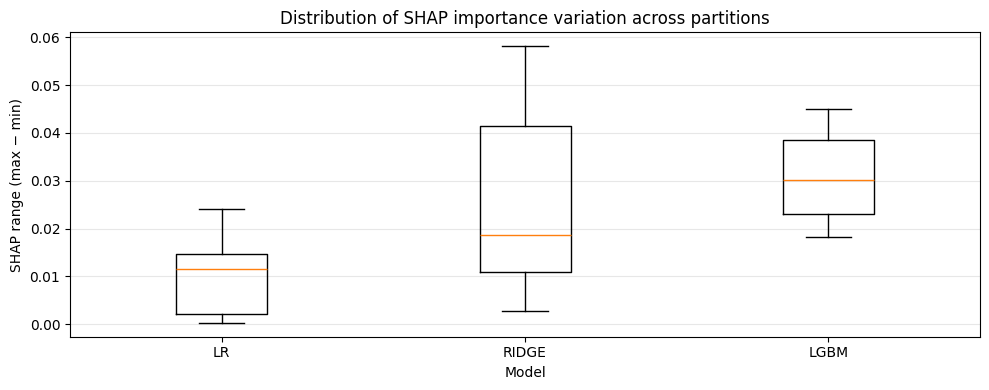

In [10]:
import matplotlib.pyplot as plt

data = [
    results_variation[m]["range"].dropna().values
    for m in results_variation.keys()
]

labels = list(results_variation.keys())

plt.figure(figsize=(10,4))

plt.boxplot(
    data,
    labels=labels,
    showfliers=False
)

plt.title("Distribution of SHAP importance variation across partitions")
plt.ylabel("SHAP range (max − min)")
plt.xlabel("Model")

plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

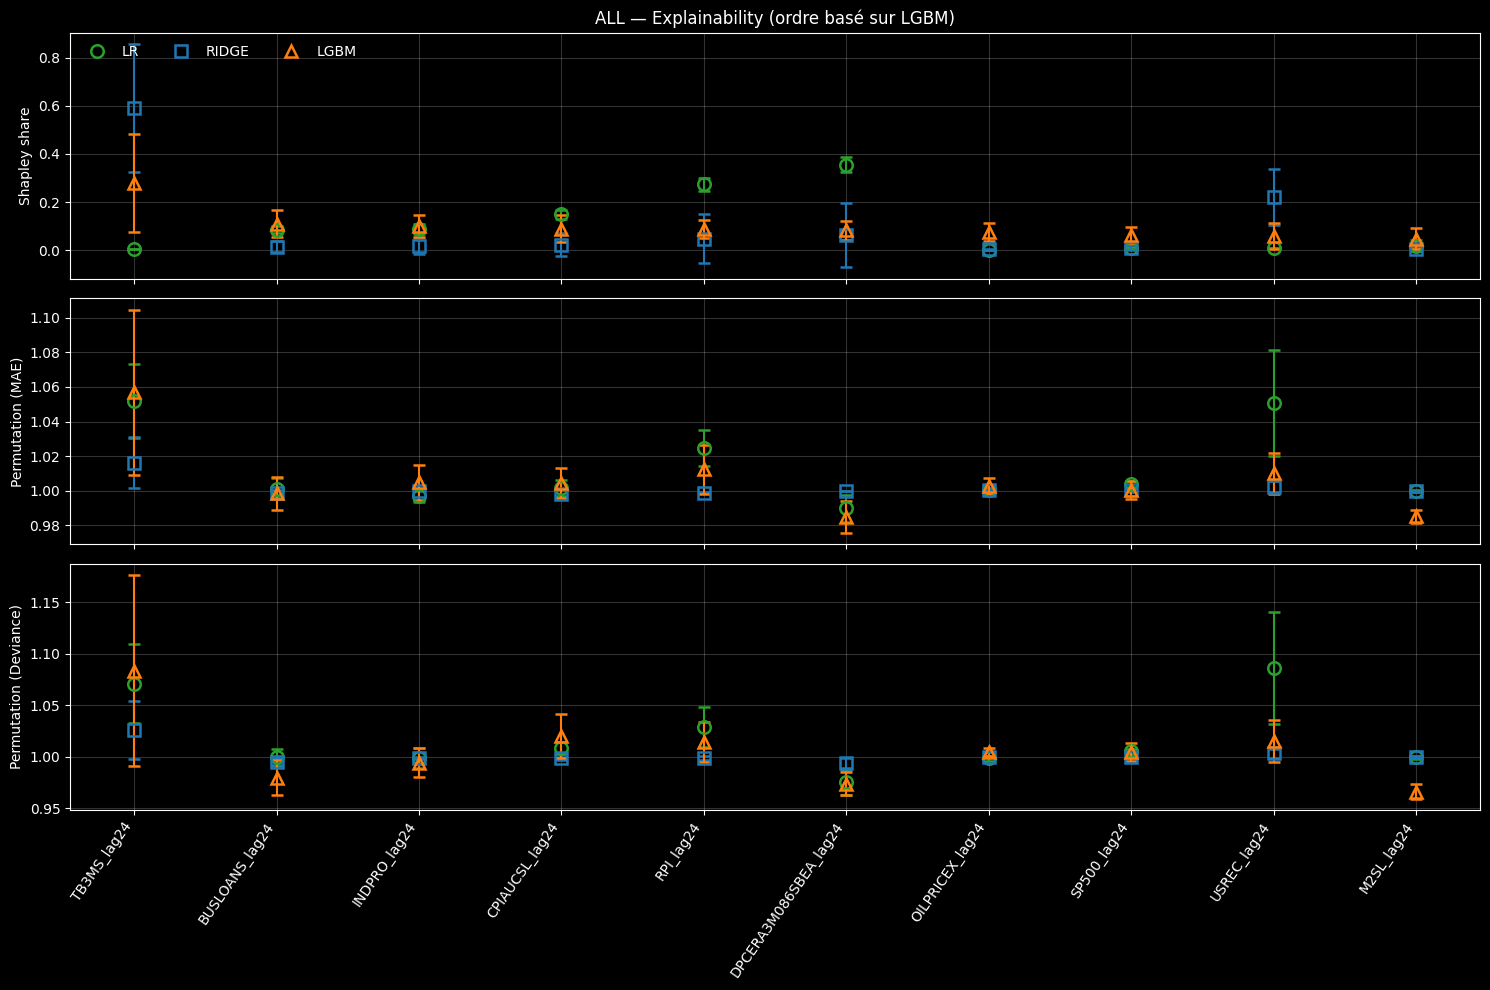

In [11]:
# ============================================================
# Même graphique mais pour ALL uniquement
# Juxtaposition multi-modèles — ordre basé sur LGBM (ALL)
# 3 lignes (metrics) x 1 partition ("ALL")
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("dark_background")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _prep_perm_df(df):
    if df is None or not {"feature","ratio_mean"}.issubset(df.columns):
        return None
    out = df[["feature","ratio_mean"]].copy()
    out = out.rename(columns={"ratio_mean":"mean"})
    out["std"] = df["ratio_std"] if "ratio_std" in df.columns else np.nan
    return out.set_index("feature").astype(float)

def _prep_shap_df(df):
    if df is None or not {"feature","shap_share_mean"}.issubset(df.columns):
        return None
    out = df[["feature","shap_share_mean"]].copy()
    out = out.rename(columns={"shap_share_mean":"mean"})
    out["std"] = df["shap_share_std"] if "shap_share_std" in df.columns else np.nan
    return out.set_index("feature").astype(float)

def _model_styles():
    return {
        "LR":    dict(color="#2ca02c", marker="o"),
        "RIDGE": dict(color="#1f77b4", marker="s"),
        "LGBM":  dict(color="#ff7f0e", marker="^"),
    }

def _order_by_lgbm(shap_map, top_k):
    df_lgbm = shap_map.get("LGBM")
    if df_lgbm is None:
        return []
    return (
        df_lgbm["mean"]
        .sort_values(ascending=False)
        .head(top_k)
        .index
        .tolist()
    )

# ------------------------------------------------------------
# Plot ALL uniquement
# ------------------------------------------------------------
def plot_importance_ALL_lgbm_order(
    results_shap_share_by_part,
    results_perm_mae_by_part,
    results_perm_dev_by_part,
    models=("LR","RIDGE","LGBM"),
    top_k=12,
    figsize=(15, 10),
    rotate=55,
    markersize=9,
    mew=1.8,
    elinewidth=1.5,
    capsize=4,
    align_vertical=True,   # True => mêmes x pour les 3 modèles
):
    part = "ALL"
    styles = _model_styles()
    row_titles = ["Shapley share", "Permutation (MAE)", "Permutation (Deviance)"]

    # ---- récupérer DF ALL par modèle
    shap_map, pmae_map, pdev_map = {}, {}, {}
    for m in models:
        shap_map[m] = _prep_shap_df(results_shap_share_by_part.get(part, {}).get(m))
        pmae_map[m] = _prep_perm_df(results_perm_mae_by_part.get(part, {}).get(m))
        pdev_map[m] = _prep_perm_df(results_perm_dev_by_part.get(part, {}).get(m))

    # ---- ordre basé sur LGBM (ALL)
    order = _order_by_lgbm(shap_map, top_k=top_k)
    if not order:
        raise ValueError("Pas de SHAP LGBM dispo pour la partition ALL (ou DF vide).")

    x = np.arange(len(order))
    panels = [shap_map, pmae_map, pdev_map]

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

    for row, ax in enumerate(axes):
        data_map = panels[row]

        for m in models:
            dfm = data_map.get(m)
            if dfm is None:
                continue

            M = dfm.reindex(order)
            y = M["mean"].values
            yerr = M["std"].values if "std" in M.columns else None
            if yerr is not None and np.all(~np.isfinite(yerr)):
                yerr = None

            st = styles[m]

            xv = x if align_vertical else x  # (ici align_vertical True => même x)

            ax.errorbar(
                xv, y, yerr=yerr,
                fmt=st["marker"],
                ms=markersize, mew=mew, mfc="none",
                elinewidth=elinewidth, ecolor=st["color"],
                capsize=capsize,
                linestyle="none",
                color=st["color"]
            )

        ax.set_ylabel(row_titles[row])
        ax.grid(True, alpha=0.2)

    axes[0].set_title("ALL — Explainability (ordre basé sur LGBM)")
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(order, rotation=rotate, ha="right")

    # ---- légende
    handles = [
        plt.Line2D([], [], marker=styles[m]["marker"], linestyle="none",
                   color=styles[m]["color"], label=m,
                   markerfacecolor="none", markeredgewidth=mew, markersize=markersize)
        for m in models
    ]
    axes[0].legend(handles=handles, loc="upper left", frameon=False, ncol=len(handles))

    plt.tight_layout()
    return fig


# ============================================================
# APPEL — ALL
# ============================================================
fig = plot_importance_ALL_lgbm_order(
    results_shap_share_by_part=results_shap_share_by_part,
    results_perm_mae_by_part=results_perm_mae_by_part,
    results_perm_dev_by_part=results_perm_dev_by_part,
    models=("LR","RIDGE","LGBM"),
    top_k=12,
    figsize=(15, 10),
    rotate=55
)

plt.show()

In [12]:
# ============================================================
# Produire le tableau Top-5 (Rank_1..Rank_5) par (model, partition)
# ✅ Même logique que ton plot : ordre basé sur LGBM (SHAP share)
#    -> pour chaque partition, on prend le Top5 des features de LGBM,
#       puis on met ces features comme Rank_1..Rank_5 pour TOUS les modèles.
# ============================================================

import numpy as np
import pandas as pd

# -----------------------
# Helpers (SHAP)
# -----------------------
def _prep_shap_df(df):
    if df is None or not {"feature","shap_share_mean"}.issubset(df.columns):
        return None
    out = df[["feature","shap_share_mean"]].copy()
    out = out.rename(columns={"shap_share_mean":"mean"})
    return out.set_index("feature").astype(float)

def _order_by_lgbm(results_shap_share_by_part, part, top_k=5):
    df_lgbm = _prep_shap_df(results_shap_share_by_part.get(part, {}).get("LGBM"))
    if df_lgbm is None:
        return []
    return (
        df_lgbm["mean"]
        .sort_values(ascending=False)
        .head(top_k)
        .index
        .tolist()
    )

# -----------------------
# Build pivot table
# -----------------------
models = ["LGBM", "LR", "RIDGE"]   # ordre d’affichage
partitions_order = ["1990-1999", "2000-2008", "2009-2019", "2020-end"]
top_k = 5

rows = []
for part in partitions_order:
    order_feats = _order_by_lgbm(results_shap_share_by_part, part, top_k=top_k)
    if not order_feats:
        continue

    for m in models:
        row = {
            "model": m,
            "partition": part,
        }
        for i in range(top_k):
            row[f"Rank_{i+1}"] = order_feats[i] if i < len(order_feats) else np.nan
        rows.append(row)

rank_table = pd.DataFrame(rows)

# Tri propre + index "rank" comme dans ton exemple
rank_table = (
    rank_table
    .sort_values(["model","partition"])
    .reset_index(drop=True)
    .reset_index()
    .rename(columns={"index":"rank"})
)

rank_table

,rank,model,partition,Rank_1,Rank_2,Rank_3,Rank_4,Rank_5
0,0,LGBM,1990-1999,TB3MS_lag24,BUSLOANS_lag24,DPCERA3M086SBEA_lag24,RPI_lag24,OILPRICEX_lag24
1,1,LGBM,2000-2008,TB3MS_lag24,BUSLOANS_lag24,INDPRO_lag24,RPI_lag24,DPCERA3M086SBEA_lag24
2,2,LGBM,2009-2019,TB3MS_lag24,INDPRO_lag24,CPIAUCSL_lag24,BUSLOANS_lag24,RPI_lag24
3,3,LGBM,2020-end,TB3MS_lag24,INDPRO_lag24,CPIAUCSL_lag24,BUSLOANS_lag24,RPI_lag24
4,4,LR,1990-1999,TB3MS_lag24,BUSLOANS_lag24,DPCERA3M086SBEA_lag24,RPI_lag24,OILPRICEX_lag24
5,5,LR,2000-2008,TB3MS_lag24,BUSLOANS_lag24,INDPRO_lag24,RPI_lag24,DPCERA3M086SBEA_lag24
6,6,LR,2009-2019,TB3MS_lag24,INDPRO_lag24,CPIAUCSL_lag24,BUSLOANS_lag24,RPI_lag24
7,7,LR,2020-end,TB3MS_lag24,INDPRO_lag24,CPIAUCSL_lag24,BUSLOANS_lag24,RPI_lag24
8,8,RIDGE,1990-1999,TB3MS_lag24,BUSLOANS_lag24,DPCERA3M086SBEA_lag24,RPI_lag24,OILPRICEX_lag24
9,9,RIDGE,2000-2008,TB3MS_lag24,BUSLOANS_lag24,INDPRO_lag24,RPI_lag24,DPCERA3M086SBEA_lag24


# fonction shap

In [13]:
# =========================================================
# Vérification X_by_run
# =========================================================
print("len(X_by_run):", len(X_by_run))
print("X_by_run keys:", list(X_by_run.keys())[:20])

for k, v in X_by_run.items():
    print(k, "| shape =", v.shape, "| cols sample =", list(v.columns[:10]))

len(X_by_run): 0
X_by_run keys: []


In [14]:
# =========================================================
# Vérification X_dict
# =========================================================
print("X_dict keys:", list(X_dict.keys()))

for k, v in X_dict.items():
    print(k, "| shape =", v.shape)
    print("  first cols:", list(v.columns[:10]))
    print()

X_dict keys: []


In [15]:
# ============================================================
# Functional-form plots — GRID (rows=variables, cols=models)
# + filtre par dates
# + pretty labels
# + compatible avec models_dict / X_dict issus de MLflow
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------
# DARK THEME
# ------------------------------------------------------------
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor":   "#111111",
    "savefig.facecolor":"#0d0d0d",
    "text.color":       "#e5e5e5",
    "axes.edgecolor":   "#bfbfbf",
    "axes.labelcolor":  "#e5e5e5",
    "xtick.color":      "#d8d8d8",
    "ytick.color":      "#d8d8d8",
    "grid.color":       "#5a5a5a",
})

_DARK_LINE = "#ffffff"
_DARK_ZERO = "#7a5a5a"
_DARK_NA   = "#a5a5a5"
_DARK_GRID = (0.25, ":")

_DARK_COLORS = (
    "#7fdfff",  # cyan
    "#ffd166",  # jaune
    "#ff7f7f",  # rouge clair
    "#9d7aff",  # violet
    "#8bd17c",  # vert
    "#f29ae1",  # rose
)

# ------------------------------------------------------------
# Helpers modèles
# ------------------------------------------------------------
def _unwrap_model(m):
    base = m
    if hasattr(base, "_base"):
        try:
            base = base._base
        except Exception:
            pass

    try:
        from sklearn.pipeline import Pipeline
        if isinstance(base, Pipeline):
            base = base.steps[-1][1]
    except Exception:
        pass

    return base


def _name_blob(model) -> str:
    cls = type(model)
    return f"{cls.__name__}|{getattr(cls, '__module__', '')}".lower()


def _is_tree_model(model) -> bool:
    blob = _name_blob(model)
    keys = (
        "lgbm", "lightgbm", "xgboost", "catboost",
        "histgradient", "randomforest", "gradientboost"
    )
    return any(k in blob for k in keys)

# ------------------------------------------------------------
# Préprocessing safe
# ------------------------------------------------------------
def _apply_prep(X: pd.DataFrame, prep):
    if prep is None:
        return X

    if hasattr(prep, "transform"):
        Xp = prep.transform(X)
        try:
            return pd.DataFrame(Xp, index=X.index, columns=X.columns)
        except Exception:
            return pd.DataFrame(Xp, index=X.index)

    Xp = X.copy()

    if isinstance(prep, dict):
        lower = prep.get("lower_wins", prep.get("lower", None))
        upper = prep.get("upper_wins", prep.get("upper", None))

        if lower is not None and upper is not None:
            lo = pd.Series(lower, index=Xp.columns) if not isinstance(lower, pd.Series) else lower.reindex(Xp.columns)
            up = pd.Series(upper, index=Xp.columns) if not isinstance(upper, pd.Series) else upper.reindex(Xp.columns)
            Xp = Xp.clip(lower=lo, upper=up, axis=1)

        if prep.get("norm", False):
            mean = prep.get("mean", None)
            std  = prep.get("std", None)
            if mean is not None and std is not None:
                mean_s = pd.Series(mean, index=Xp.columns) if not isinstance(mean, pd.Series) else mean.reindex(Xp.columns)
                std_s  = pd.Series(std,  index=Xp.columns) if not isinstance(std,  pd.Series) else std.reindex(Xp.columns)
                Xp = (Xp - mean_s) / std_s.replace(0, 1)

    return Xp

# ------------------------------------------------------------
# Helpers LightGBM
# ------------------------------------------------------------
def _lgbm_feature_names(model):
    names = getattr(model, "feature_name_", None)
    if names:
        return list(names)

    booster = getattr(model, "_Booster", None)
    if booster is not None and hasattr(booster, "feature_name"):
        try:
            return list(booster.feature_name())
        except Exception:
            pass

    return None


def _reorder_X_for_lgbm(model, X: pd.DataFrame) -> pd.DataFrame:
    names = _lgbm_feature_names(model)
    if names:
        cols = [c for c in names if c in X.columns]
        if cols:
            return X.loc[:, cols]
    return X

# ------------------------------------------------------------
# SHAP / contributions
# ------------------------------------------------------------
def _compute_phi(model, X: pd.DataFrame, prep=None) -> np.ndarray:
    base = _unwrap_model(model)

    # modèles arbres -> SHAP TreeExplainer
    if _is_tree_model(base):
        X_ord = _reorder_X_for_lgbm(base, X)
        Xp = _apply_prep(X_ord, prep).astype(float)

        try:
            expl = shap.TreeExplainer(base, Xp, check_additivity=False)
            sv = expl.shap_values(Xp)
        except TypeError:
            expl = shap.TreeExplainer(base, Xp)
            sv = expl.shap_values(Xp, check_additivity=False)

        phi = sv[0] if isinstance(sv, list) else np.asarray(sv)
        if np.ndim(phi) == 3:
            phi = phi[0]

        if phi.shape[1] != Xp.shape[1]:
            raise ValueError("Dimensions SHAP incohérentes (arbres).")

        # réaligner sur les colonnes originales de X si besoin
        if list(X_ord.columns) != list(X.columns):
            phi_df = pd.DataFrame(phi, index=Xp.index, columns=X_ord.columns)
            phi_df = phi_df.reindex(columns=X.columns, fill_value=np.nan)
            return phi_df.to_numpy()

        return np.asarray(phi)

    # modèles linéaires -> contributions exactes
    coef = getattr(base, "coef_", None)
    if coef is None:
        raise TypeError(f"Modèle non supporté (coef_ absent et non-arbre): {type(base)}")

    Xp = _apply_prep(X, prep).astype(float)
    mu = np.nanmean(Xp, axis=0)
    Xc = Xp - mu
    phi = Xc.to_numpy() * np.asarray(coef).reshape(1, -1)
    return phi

# ------------------------------------------------------------
# Alias features
# ------------------------------------------------------------
_alias_map = {
    "UNRATE_lags_12": ["UNRATE_lag12", "UNRATE_lags12", "lag12_UNRATE", "UNRATE_L12", "UNRATE_LAG_12", "UNRATE_LAG12"],
    "INDPRO": ["INDPRO_lag12"],
    "BUSLOANS": ["BUSLOANS_lag12"],
    "TB3MS": ["TB3MS_lag12"],
    "RPI": ["RPI_lag12"],
    "M2SL": ["M2SL_lag12"],
    "OILPRICEX": ["OILPRICEX_lag12"],
    "CPIAUCSL": ["CPIAUCSL_lag12"],
    "DPCERA3M086SBEA": ["DPCERA3M086SBEA_lag12"],
    "S&P500": ["SP500_lag12", "SP500", "S_P_500", "SANDP500", "SP_500", "S&P_500"],
    "SP500": ["SP500_lag12"],
}

def _resolve_feature_name(col_list, feat):
    if feat in col_list:
        return feat

    for alt in _alias_map.get(feat, []):
        if alt in col_list:
            return alt

    if f"{feat}_lag12" in col_list:
        return f"{feat}_lag12"

    f = re.sub(r"[^A-Z0-9]", "", str(feat).upper())
    for col in col_list:
        c = re.sub(r"[^A-Z0-9]", "", str(col).upper())
        if c == f:
            return col

    return None

# ------------------------------------------------------------
# Helpers dates
# ------------------------------------------------------------
def _ensure_ms_ts(x):
    return pd.Timestamp(x).to_period("M").to_timestamp(how="start").normalize()


def _filter_X_by_date(X: pd.DataFrame, start_date=None, end_date=None, date_col: str = "ds") -> pd.DataFrame:
    if start_date is None and end_date is None:
        return X

    start = _ensure_ms_ts(start_date) if start_date is not None else None
    end   = _ensure_ms_ts(end_date)   if end_date is not None else None

    # cas index datetime
    if isinstance(X.index, pd.DatetimeIndex):
        out = X.copy()
        if start is not None:
            out = out.loc[out.index >= start]
        if end is not None:
            out = out.loc[out.index <= end]
        return out

    # cas colonne de date
    if date_col in X.columns:
        out = X.copy()
        out[date_col] = (
            pd.to_datetime(out[date_col], errors="coerce")
              .dt.to_period("M")
              .dt.to_timestamp(how="start")
              .dt.normalize()
        )
        if start is not None:
            out = out[out[date_col] >= start]
        if end is not None:
            out = out[out[date_col] <= end]
        return out

    return X

# ------------------------------------------------------------
# Pretty labels
# ------------------------------------------------------------
def _pretty_feat_label(feat: str, pretty_map=None):
    if not pretty_map:
        return feat
    return pretty_map.get(feat, feat)

# ------------------------------------------------------------
# Plot principal
# ------------------------------------------------------------
def plot_functional_grid(
    models_dict,
    X_dict,
    selected_vars,
    *,
    start_date=None,
    end_date=None,
    date_col: str = "ds",
    poly_deg_lgbm: int = 3,
    scatter_alpha: float = 0.70,
    s: int = 18,
    colors=_DARK_COLORS,
    figsize_per_cell=(3.1, 2.7),
    sharey: bool = False,
    max_n: int | None = 2000,
    random_state: int = 42,
    _pretty_label_from_feat=None,
    use_pretty_labels: bool = True,
):
    model_names = list(models_dict.keys())

    # filtrage par date
    X_dict_f = {}
    for m in model_names:
        if m not in X_dict:
            raise KeyError(f"X_dict ne contient pas la clé modèle: {m}")
        X_dict_f[m] = _filter_X_by_date(
            X_dict[m],
            start_date=start_date,
            end_date=end_date,
            date_col=date_col,
        )

    # index commun après filtre
    common_index = None
    for m in model_names:
        idx = X_dict_f[m].index
        common_index = idx if common_index is None else common_index.intersection(idx)

    if common_index is None or len(common_index) == 0:
        raise RuntimeError("Index commun vide entre modèles après filtre date. Essaie un intervalle plus large.")

    # figure
    n_rows = len(selected_vars)
    n_cols = len(model_names)

    fig_w = max(6.0, n_cols * figsize_per_cell[0])
    fig_h = max(6.0, n_rows * figsize_per_cell[1])

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), sharey=sharey)
    fig.patch.set_facecolor("#0d0d0d")

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    # boucle par modèle
    for c, (mname, (model, prep)) in enumerate(models_dict.items()):
        X_full_all = X_dict_f[mname].loc[common_index].copy()

        if max_n is not None and len(X_full_all) > max_n:
            X_full_all = X_full_all.sample(max_n, random_state=random_state).sort_index()

        base = _unwrap_model(model)
        is_linear = hasattr(base, "coef_") and not _is_tree_model(base)

        phi = np.asarray(_compute_phi(model, X_full_all, prep=prep))

        X_plot_all = _apply_prep(X_full_all, prep) if is_linear else X_full_all
        if isinstance(X_plot_all, pd.DataFrame):
            X_plot_all = X_plot_all.copy()
            X_plot_all.columns = X_full_all.columns
        else:
            X_plot_all = pd.DataFrame(X_plot_all, index=X_full_all.index, columns=X_full_all.columns)

        col_index_map = {col: j for j, col in enumerate(X_full_all.columns)}
        deg = 1 if is_linear else poly_deg_lgbm
        color_pts = colors[c % len(colors)]

        for r, feat in enumerate(selected_vars):
            ax = axes[r, c]
            ax.set_facecolor("#111111")

            resolved = _resolve_feature_name(X_full_all.columns, feat)

            ylab = _pretty_feat_label(feat, _pretty_label_from_feat) if use_pretty_labels else feat

            if resolved is None or resolved not in col_index_map:
                ax.text(
                    0.5, 0.5, "NA",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color=_DARK_NA,
                    transform=ax.transAxes,
                )
                ax.set_xticks([])
                ax.set_yticks([])
                for sp in ("top", "right"):
                    ax.spines[sp].set_visible(False)
                if r == 0:
                    ax.set_title(mname, fontsize=9, pad=4, color="#e5e5e5")
                if c == 0:
                    ax.set_ylabel(ylab, fontsize=9, color="#e5e5e5")
                continue

            j = col_index_map[resolved]
            x = X_plot_all.iloc[:, j].to_numpy()
            y = phi[:, j]

            mask = ~(np.isnan(x) | np.isnan(y))
            x, y = x[mask], y[mask]

            ax.scatter(
                x, y,
                alpha=scatter_alpha,
                s=s,
                facecolors="#0d0d0d",
                edgecolors=color_pts,
                linewidths=0.8,
            )

            if len(x) > deg + 1:
                try:
                    coefs = np.polyfit(x, y, deg=deg)
                    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
                    y_line = np.polyval(coefs, x_line)
                    ax.plot(x_line, y_line, color=_DARK_LINE, linewidth=1.2)
                except Exception:
                    pass

            ax.axhline(0, color=_DARK_ZERO, lw=0.9)
            ax.axvline(0, color=_DARK_ZERO, lw=0.9)
            ax.grid(axis="y", linestyle=_DARK_GRID[1], alpha=_DARK_GRID[0])

            if r == 0:
                ax.set_title(mname, fontsize=9, pad=4, color="#e5e5e5")
            if c == 0:
                ax.set_ylabel(ylab, fontsize=9, color="#e5e5e5")
            if r == n_rows - 1:
                ax.set_xlabel("Observed values", fontsize=8, color="#e5e5e5")

            for spine in ("top", "right"):
                ax.spines[spine].set_visible(False)
            ax.spines["left"].set_color("#bfbfbf")
            ax.spines["bottom"].set_color("#bfbfbf")

    s_txt = _ensure_ms_ts(start_date).date() if start_date is not None else "min"
    e_txt = _ensure_ms_ts(end_date).date() if end_date is not None else "max"
    fig.suptitle(f"Functional-form grid | {s_txt} → {e_txt}", y=1.01, fontsize=11, color="#e5e5e5")

    plt.tight_layout(h_pad=0.9, w_pad=0.9)
    return fig, axes

In [16]:
selected_vars = [
    "SP500_lag12",
    "INDPRO_lag12",
    "TB3MS_lag12",
    "BUSLOANS_lag12",
    "DPCERA3M086SBEA_lag12",
]

_pretty_label_from_feat = {
    "SP500_lag12": "S&P 500",
    "INDPRO_lag12": "Industrial production",
    "TB3MS_lag12": "Short-term interest rate",
    "BUSLOANS_lag12": "Business loans",
    "DPCERA3M086SBEA_lag12": "Personal consumption",
}

START_DATE = "1990-01-01"
END_DATE   = "2019-08-01"

fig, axes = plot_functional_grid(
    models_dict=models_dict,
    X_dict=X_dict,
    selected_vars=selected_vars,
    start_date=START_DATE,
    end_date=END_DATE,
    date_col="ds",
    poly_deg_lgbm=3,
    figsize_per_cell=(3.2, 2.8),
    sharey=False,
    max_n=1500,
    random_state=42,
    _pretty_label_from_feat=_pretty_label_from_feat,
    use_pretty_labels=True,
)

plt.show()

KeyError: 'X_dict ne contient pas la clé modèle: RIDGE'

In [ ]:
print("models_dict keys:", list(models_dict.keys()))
print("X_dict keys:", list(X_dict.keys()))

models_dict keys: ['RIDGE', 'LR', 'LGBM']
X_dict keys: []
